**Steps**

1)Preprocessc + EDA + Feature

2)Extract input and output col

3)Scale the values

$)Train test split

5)Train the model

6)Evaluate the model/model selection

7)Deploy the model


In [2]:
import pandas as pd
import numpy as np

# Re-creating df for standalone execution in case the previous cell wasn't run
np.random.seed(42)

n = 500

cgpa = np.round(np.random.uniform(5.0, 10.0, n), 2)
iq = np.random.randint(80, 141, n)

# Simple rule for placement
placement = ((cgpa > 7.5) & (iq > 105)).astype(int)

df = pd.DataFrame({
    'cgpa': cgpa,
    'iq': iq,
    'placement': placement
})

df.head()

,cgpa,iq,placement
0,6.87,133,0
1,9.75,96,0
2,8.66,88,0
3,7.99,112,1
4,5.78,132,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       500 non-null    float64
 1   iq         500 non-null    int64  
 2   placement  500 non-null    int64  
dtypes: float64(1), int64(2)
memory usage: 11.8 KB


In [4]:
import matplotlib.pyplot as plt

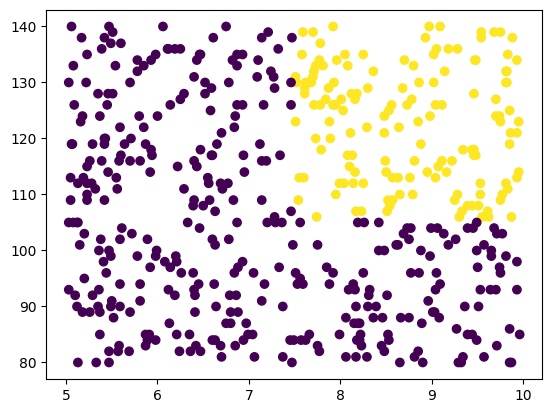

In [7]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [8]:
x = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [9]:
x

,cgpa,iq
0,6.87,133
1,9.75,96
2,8.66,88
3,7.99,112
4,5.78,132
...,...,...
495,6.77,112
496,7.92,140
497,5.39,116
498,9.87,106


In [10]:
y

,placement
0,0
1,0
2,0
3,1
4,0
...,...
495,0
496,1
497,0
498,1


In [11]:
y.shape

(500,)

In [12]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [13]:
x_train

,cgpa,iq
428,6.75,87
490,7.28,106
53,9.47,134
336,9.28,110
154,9.93,113
...,...,...
22,6.46,135
72,5.03,93
493,5.94,117
15,5.92,97


In [14]:
y_train

,placement
428,0
490,0
53,1
336,1
154,1
...,...
22,0
72,0
493,0
15,0


In [15]:
x_test

,cgpa,iq
129,7.55,113
280,9.45,104
440,5.42,138
384,8.68,129
225,6.22,115
...,...,...
387,5.89,84
117,5.93,118
468,6.12,93
395,9.65,99


In [18]:
from sklearn.preprocessing import StandardScaler

In [20]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)

In [21]:
x_train

array([[-5.27659396e-01, -1.24467331e+00],
       [-1.73447079e-01, -1.69483817e-01],
       [ 1.29018495e+00,  1.41500596e+00],
       [ 1.16320318e+00,  5.68718650e-02],
       [ 1.59761451e+00,  2.26638626e-01],
       [ 8.95873125e-01,  5.66172149e-01],
       [ 9.09239628e-01, -1.64079575e+00],
       [-1.44326482e+00, -3.95839498e-01],
       [ 1.19661943e+00, -1.12894896e-01],
       [ 2.27547998e-01, -8.48550862e-01],
       [ 2.54281003e-01, -7.35373021e-01],
       [-9.75437232e-01, -6.22195180e-01],
       [-5.31485558e-02,  1.18865027e+00],
       [-1.30291654e+00, -8.48550862e-01],
       [ 7.38332185e-02,  1.18865027e+00],
       [-4.67510135e-01, -7.35373021e-01],
       [-1.63707911e+00,  9.62294592e-01],
       [-1.15588502e+00, -8.48550862e-01],
       [ 4.21362285e-01, -1.58420683e+00],
       [ 8.49090366e-01,  3.96405388e-01],
       [-9.01921468e-01,  1.52818380e+00],
       [ 1.09637066e+00,  1.52818380e+00],
       [ 2.81014008e-01,  1.41500596e+00],
       [-7.

In [22]:
x_test = scaler.transform(x_test)

In [23]:
x_test

array([[ 7.00070571e-03,  2.26638626e-01],
       [ 1.27681845e+00, -2.82661658e-01],
       [-1.41653182e+00,  1.64136164e+00],
       [ 7.62208100e-01,  1.13206135e+00],
       [-8.81871714e-01,  3.39816467e-01],
       [-7.14790432e-01,  1.47159488e+00],
       [ 1.47731599e+00, -7.35373021e-01],
       [ 6.41909577e-01,  2.83227547e-01],
       [ 4.28045536e-01,  1.07547243e+00],
       [ 1.09637066e+00, -4.52428419e-01],
       [ 6.71499672e-02,  1.18865027e+00],
       [-1.11578551e+00, -1.35785115e+00],
       [ 4.14679033e-01,  1.01888351e+00],
       [-9.55387478e-01,  1.52818380e+00],
       [-6.34591417e-01,  4.52994308e-01],
       [ 1.27013520e+00, -1.35785115e+00],
       [ 3.47846521e-01, -1.18808438e+00],
       [-4.47460381e-01,  9.62294592e-01],
       [-5.07609642e-01,  1.18865027e+00],
       [ 6.08493320e-01, -1.47102899e+00],
       [-1.30291654e+00, -3.95839498e-01],
       [-1.19981069e-01, -2.26072737e-01],
       [ 7.75574602e-01,  1.41500596e+00],
       [-1.

In [24]:
from sklearn.linear_model import LogisticRegression

In [26]:
clf = LogisticRegression()

In [27]:
#training
clf.fit(x_train,y_train)

LogisticRegression()

In [30]:
y_pred = clf.predict(x_test)

In [29]:
y_test

,placement
129,1
280,0
440,0
384,1
225,0
...,...
387,0
117,0
468,0
395,0


In [31]:
from sklearn.metrics import accuracy_score

In [32]:
accuracy_score(y_test,y_pred)

0.87

In [33]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

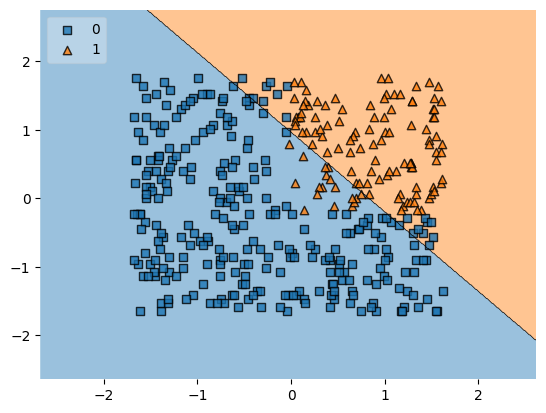

In [34]:
plot_decision_regions(x_train, y_train.values, clf=clf, legend=2)

In [36]:
import pickle

In [37]:
import pickle
pickle.dump(clf,open('model.pkl','wb'))